# Import

In [23]:
import numpy as np
import pandas as pd # type: ignore
from PIL import Image
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
from rbf_main import RBF, one_hot, set_seed, rbf_classification_training, confusion_matrix

## Separation du dataSet

In [2]:
np.random.seed(12)
NB_IMG_PER_CLASSES = 1000

base = Path("data")
classes = ["compost", "dechets_chimiques", "recyclable"]

rows = []
for cls in classes:
    images = sorted((base / cls).glob("*.jpg"))[:NB_IMG_PER_CLASSES]
    for img_path in images:
        rows.append({
            "path": str(img_path),
            "nom_image": img_path.name,
            "classe": cls
        })

df = pd.DataFrame(rows)

def assign_split(n, ratios=(0.70, 0.28, 0.02)):
    labels = np.array(["train"] * n)
    idx = np.random.permutation(n)
    t1 = int(n * ratios[0])
    t2 = int(n * (ratios[0] + ratios[1]))
    labels[idx[t1:t2]] = "val"
    labels[idx[t2:]] = "test"
    return labels

df["cat"] = df.groupby("classe")["path"].transform(lambda x: assign_split(len(x)))

print(f"Total : {len(df)} images")
print(df.groupby("classe")["cat"].value_counts())
df.head()

Total : 3000 images
classe             cat  
compost            train    700
                   val      280
                   test      20
dechets_chimiques  train    700
                   val      280
                   test      20
recyclable         train    700
                   val      280
                   test      20
Name: count, dtype: int64


,path,nom_image,classe,cat
0,data\compost\compost_0001.jpg,compost_0001.jpg,compost,train
1,data\compost\compost_0002.jpg,compost_0002.jpg,compost,train
2,data\compost\compost_0003.jpg,compost_0003.jpg,compost,val
3,data\compost\compost_0004.jpg,compost_0004.jpg,compost,train
4,data\compost\compost_0005.jpg,compost_0005.jpg,compost,train


## Transformation des données (redimension + gray lvl)

In [3]:
IMG = 24
IMG_SIZE = (IMG, IMG)

def load_image(path):
    try:
        img = Image.open(path).convert("L")
        img = img.resize(IMG_SIZE)
        return np.array(img, dtype=np.float32).flatten() / 255.0
    except (OSError, IOError):
        return None

df["pixels"] = [load_image(p) for p in tqdm(df["path"], desc="Chargement")]

n_before = len(df)
df = df.dropna(subset=["pixels"]).reset_index(drop=True)
print(f"Images corrompues supprimées : {n_before - len(df)}")

X_train = np.stack(df[df["cat"] == "train"]["pixels"].values)
X_val   = np.stack(df[df["cat"] == "val"]["pixels"].values)
X_test  = np.stack(df[df["cat"] == "test"]["pixels"].values)

label_map = {cls: i for i, cls in enumerate(classes)}
y_train = df[df["cat"] == "train"]["classe"].map(label_map).values
y_val   = df[df["cat"] == "val"]["classe"].map(label_map).values
y_test  = df[df["cat"] == "test"]["classe"].map(label_map).values

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Labels:  {label_map}")

Chargement: 100%|██████████| 3000/3000 [00:24<00:00, 120.65it/s]

Images corrompues supprimées : 0
X_train: (2100, 576)  y_train: (2100,)
X_val:   (840, 576)    y_val:   (840,)
X_test:  (60, 576)   y_test:  (60,)
Labels:  {'compost': 0, 'dechets_chimiques': 1, 'recyclable': 2}


In [ ]:
# Xp - A - Identification du nombre de centre optimaux - 24*24 | Grey Scale - KPP -> ~500 minutes

In [5]:
seeds_list = [
    [6, 8, 12, 48, 75]
    ,[1, 5, 142, 24, 12]
    ,[3, 8, 9]
]

gammas = [0.01, 0.1, 0.5, 0.8, 2] # 0.5

# HP
nb_epoch      = 100
learning_rate = 0.1
gamma         = 0.5
seeds         = seeds_list[2]
list_nb_centre = np.arange(1500, 2000, 100)

# Train
results_par_k = {}
for c in list_nb_centre:
    c = int(c)
    print(f"Batch nb_centre -> {c}")
    results_par_k[c] = rbf_classification_training(
                            nb_epoch=nb_epoch,
                            learning_rate=learning_rate,
                            nb_centre=c,
                            gamma=gamma,
                            seeds=seeds,
                            X_train=X_train, X_val=X_val,
                            y_train=y_train, y_val=y_val,
                        )

Batch nb_centre -> 1500


seed=9: 100%|██████████| 100/100 [07:34<00:00,  4.55s/it, acc=0.537, train=0.0743, val=0.2917]


Batch nb_centre -> 1600


seed=9: 100%|██████████| 100/100 [08:29<00:00,  5.10s/it, acc=0.539, train=0.0568, val=0.2906]


Batch nb_centre -> 1700


seed=9: 100%|██████████| 100/100 [08:05<00:00,  4.85s/it, acc=0.535, train=0.0387, val=0.2894]


Batch nb_centre -> 1800


seed=9: 100%|██████████| 100/100 [08:40<00:00,  5.20s/it, acc=0.567, train=0.0218, val=0.2866]


Batch nb_centre -> 1900


seed=9: 100%|██████████| 100/100 [09:07<00:00,  5.47s/it, acc=0.555, train=0.0060, val=0.2858]


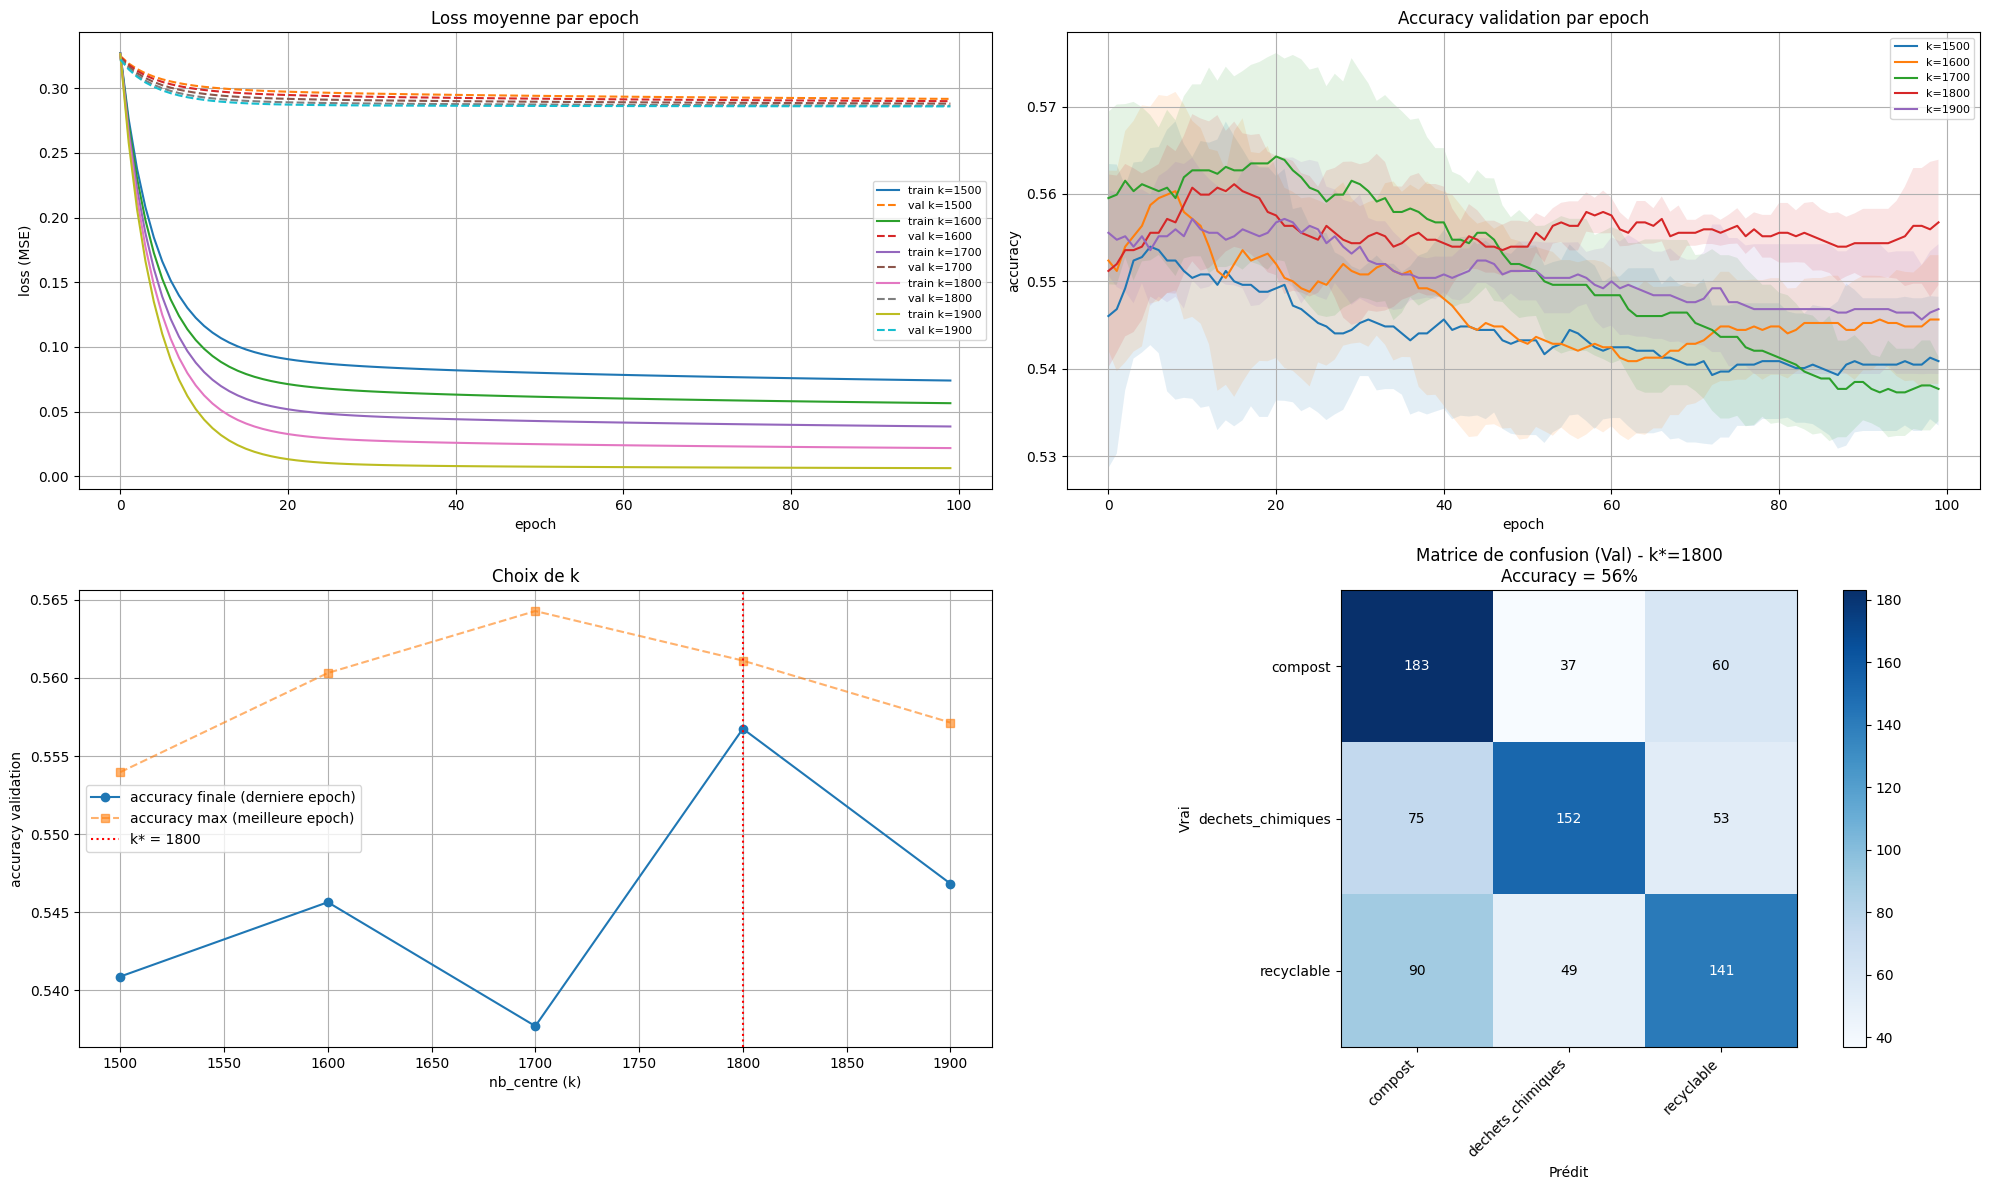

In [6]:

ks     = list(results_par_k.keys())
epochs = np.arange(nb_epoch)

# resumes par k
val_acc_final = [results_par_k[c]["accs_mean"][-1]  for c in ks]  # derniere epoch
val_acc_max   = [results_par_k[c]["accs_mean"].max() for c in ks] # meilleure epoch
k_star        = ks[int(np.argmax(val_acc_final))]                 # k retenu

fig, ((axA, axB), (axC, axD)) = plt.subplots(2, 2, figsize=(20, 12))

# --- A : loss par epoch ---
for c in ks:
    r = results_par_k[c]
    axA.plot(epochs, r["train_loss_mean"], label=f"train k={c}")
    axA.plot(epochs, r["val_loss_mean"], "--", label=f"val k={c}")
axA.set_xlabel("epoch"); axA.set_ylabel("loss (MSE)")
axA.set_title("Loss moyenne par epoch"); axA.legend(fontsize=8); axA.grid(True)

# --- B : accuracy par epoch (sert a regler nb_epoch) ---
for c in ks:
    r = results_par_k[c]
    axB.plot(epochs, r["accs_mean"], label=f"k={c}")
    axB.fill_between(epochs, r["accs_mean"] - r["accs_std"],
                     r["accs_mean"] + r["accs_std"], alpha=0.12)
axB.set_xlabel("epoch"); axB.set_ylabel("accuracy")
axB.set_title("Accuracy validation par epoch"); axB.legend(fontsize=8); axB.grid(True)

# --- C : choix de k ---
axC.plot(ks, val_acc_final, "o-", label="accuracy finale (derniere epoch)")
axC.plot(ks, val_acc_max, "s--", alpha=0.6, label="accuracy max (meilleure epoch)")
axC.axvline(k_star, color="red", linestyle=":", label=f"k* = {k_star}")
axC.set_xlabel("nb_centre (k)"); axC.set_ylabel("accuracy validation")
axC.set_title("Choix de k"); axC.legend(); axC.grid(True)

# --- D : matrice de confusion au k retenu ---
model_star = results_par_k[k_star]["model"]
cm = confusion_matrix(y_val, model_star.predict(X_val), 3)

im = axD.imshow(cm, cmap="Blues")
axD.set_xticks(range(3)); axD.set_xticklabels(classes, rotation=45, ha="right")
axD.set_yticks(range(3)); axD.set_yticklabels(classes)
axD.set_xlabel("Prédit"); axD.set_ylabel("Vrai")
axD.set_title(f"Matrice de confusion (Val) - k*={k_star}\n"
              f"Accuracy = {val_acc_final[ks.index(k_star)]*100:.0f}%")
thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        axD.text(j, i, int(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
fig.colorbar(im, ax=axD)

plt.tight_layout()
plt.show()

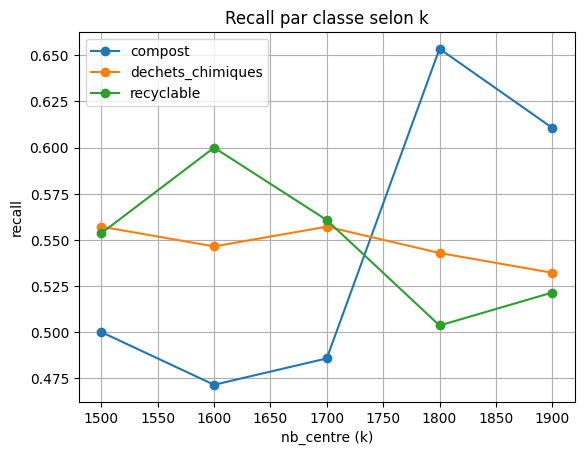

In [7]:
recall_par_classe = {cl: [] for cl in range(3)}
for c in ks:
    cm_c = confusion_matrix(y_val, results_par_k[c]["model"].predict(X_val), 3)
    per_class = cm_c.diagonal() / cm_c.sum(axis=1)   # recall (ligne = vrai)
    for cl in range(3):
        recall_par_classe[cl].append(per_class[cl])

for cl in range(3):
    plt.plot(ks, recall_par_classe[cl], "o-", label=classes[cl])
plt.xlabel("nb_centre (k)"); plt.ylabel("recall"); plt.legend(); plt.grid(True)
plt.title("Recall par classe selon k"); plt.show()

Pour kmean ++ a 1800 centre et .5 gamma, on tape du 0.56 d'acc (24*24)

In [ ]:
# Xp - B - Identification du nombre de centre optimaux - 24*24 | Grey Scale - Km | Temps de kmPP vs resultat de km naif |(init des centres = 15sec contre 35 minutes)

In [4]:
seeds_list = [
    [6, 8, 12, 48, 75]
    ,[1, 5, 142, 24, 12]
    ,[3, 8, 9]
]

gammas = [0.01, 0.1, 0.5, 0.8, 2] # 0.5

# HP
nb_epoch      = 100
learning_rate = 0.1
gamma         = 0.5
seeds         = seeds_list[2]
list_nb_centre = np.arange(1500, 2000, 100)

# Train
results_par_k = {}
for c in list_nb_centre:
    c = int(c)
    print(f"Batch nb_centre -> {c}")
    results_par_k[c] = rbf_classification_training(
                            nb_epoch=nb_epoch,
                            learning_rate=learning_rate,
                            nb_centre=c,
                            gamma=gamma,
                            seeds=seeds,
                            X_train=X_train, X_val=X_val,
                            y_train=y_train, y_val=y_val,
                        )

Batch nb_centre -> 1500


seed=9: 100%|██████████| 100/100 [07:34<00:00,  4.55s/it, acc=0.507, train=0.1484, val=0.3002]


Batch nb_centre -> 1600


seed=9: 100%|██████████| 100/100 [08:07<00:00,  4.88s/it, acc=0.502, train=0.1404, val=0.3001]


Batch nb_centre -> 1700


seed=9: 100%|██████████| 100/100 [08:06<00:00,  4.87s/it, acc=0.502, train=0.1316, val=0.2992]


Batch nb_centre -> 1800


seed=9: 100%|██████████| 100/100 [08:34<00:00,  5.14s/it, acc=0.499, train=0.1249, val=0.2984]


Batch nb_centre -> 1900


seed=9: 100%|██████████| 100/100 [09:02<00:00,  5.42s/it, acc=0.504, train=0.1185, val=0.2979]


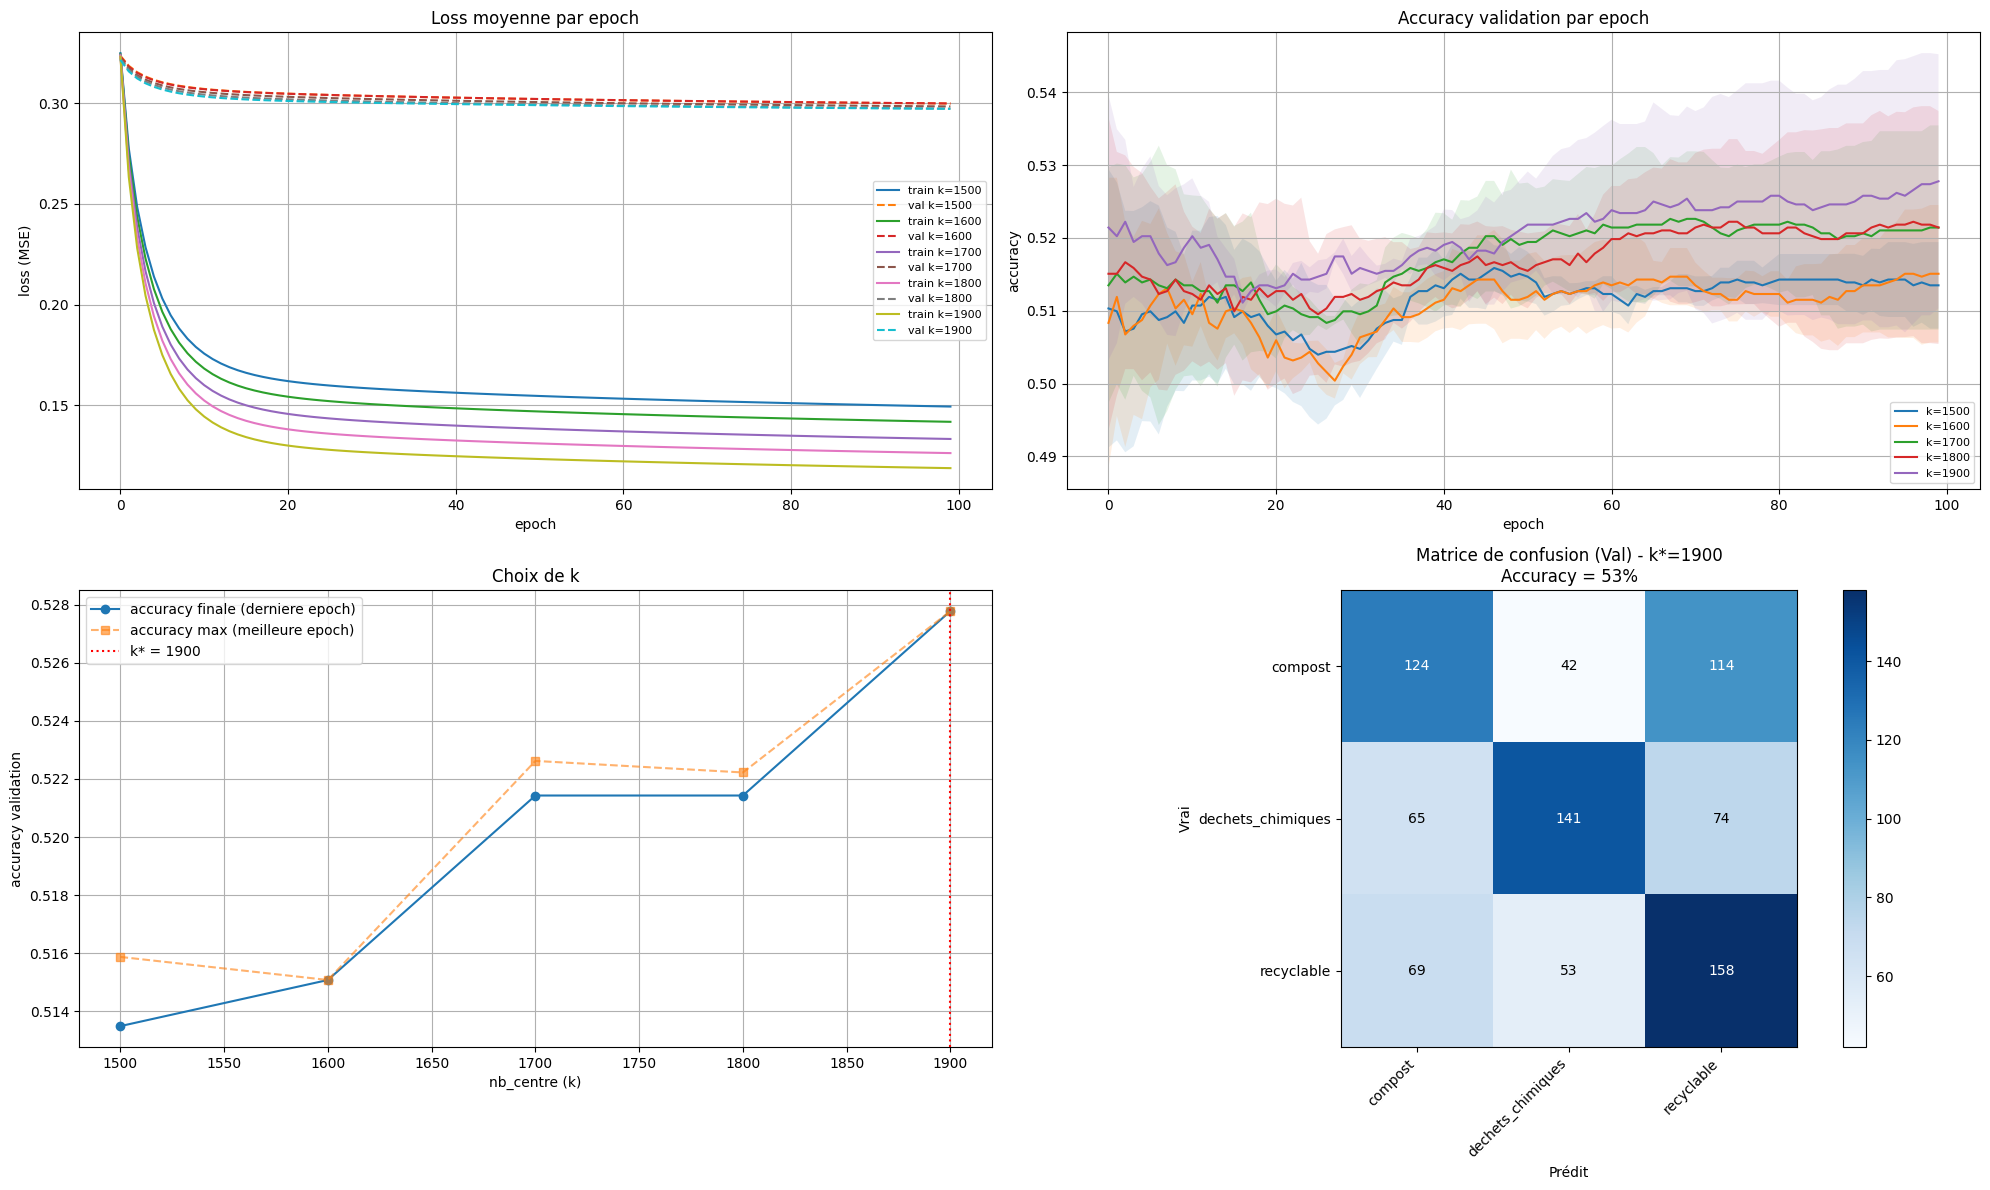

In [5]:

ks     = list(results_par_k.keys())
epochs = np.arange(nb_epoch)

# resumes par k
val_acc_final = [results_par_k[c]["accs_mean"][-1]  for c in ks]  # derniere epoch
val_acc_max   = [results_par_k[c]["accs_mean"].max() for c in ks] # meilleure epoch
k_star        = ks[int(np.argmax(val_acc_final))]                 # k retenu

fig, ((axA, axB), (axC, axD)) = plt.subplots(2, 2, figsize=(20, 12))

# --- A : loss par epoch ---
for c in ks:
    r = results_par_k[c]
    axA.plot(epochs, r["train_loss_mean"], label=f"train k={c}")
    axA.plot(epochs, r["val_loss_mean"], "--", label=f"val k={c}")
axA.set_xlabel("epoch"); axA.set_ylabel("loss (MSE)")
axA.set_title("Loss moyenne par epoch"); axA.legend(fontsize=8); axA.grid(True)

# --- B : accuracy par epoch (sert a regler nb_epoch) ---
for c in ks:
    r = results_par_k[c]
    axB.plot(epochs, r["accs_mean"], label=f"k={c}")
    axB.fill_between(epochs, r["accs_mean"] - r["accs_std"],
                     r["accs_mean"] + r["accs_std"], alpha=0.12)
axB.set_xlabel("epoch"); axB.set_ylabel("accuracy")
axB.set_title("Accuracy validation par epoch"); axB.legend(fontsize=8); axB.grid(True)

# --- C : choix de k ---
axC.plot(ks, val_acc_final, "o-", label="accuracy finale (derniere epoch)")
axC.plot(ks, val_acc_max, "s--", alpha=0.6, label="accuracy max (meilleure epoch)")
axC.axvline(k_star, color="red", linestyle=":", label=f"k* = {k_star}")
axC.set_xlabel("nb_centre (k)"); axC.set_ylabel("accuracy validation")
axC.set_title("Choix de k"); axC.legend(); axC.grid(True)

# --- D : matrice de confusion au k retenu ---
model_star = results_par_k[k_star]["model"]
cm = confusion_matrix(y_val, model_star.predict(X_val), 3)

im = axD.imshow(cm, cmap="Blues")
axD.set_xticks(range(3)); axD.set_xticklabels(classes, rotation=45, ha="right")
axD.set_yticks(range(3)); axD.set_yticklabels(classes)
axD.set_xlabel("Prédit"); axD.set_ylabel("Vrai")
axD.set_title(f"Matrice de confusion (Val) - k*={k_star}\n"
              f"Accuracy = {val_acc_final[ks.index(k_star)]*100:.0f}%")
thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        axD.text(j, i, int(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
fig.colorbar(im, ax=axD)

plt.tight_layout()
plt.show()

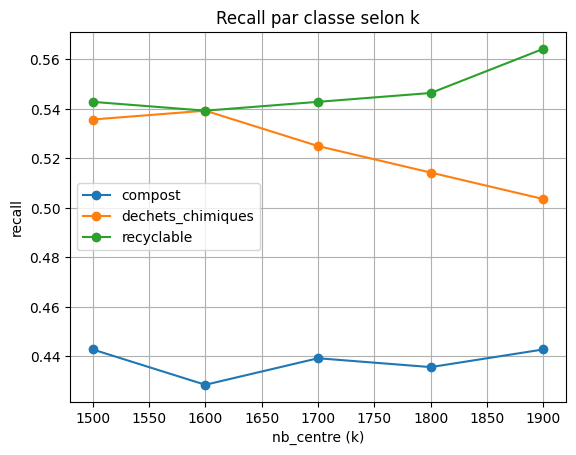

In [6]:
recall_par_classe = {cl: [] for cl in range(3)}
for c in ks:
    cm_c = confusion_matrix(y_val, results_par_k[c]["model"].predict(X_val), 3)
    per_class = cm_c.diagonal() / cm_c.sum(axis=1)   # recall (ligne = vrai)
    for cl in range(3):
        recall_par_classe[cl].append(per_class[cl])

for cl in range(3):
    plt.plot(ks, recall_par_classe[cl], "o-", label=classes[cl])
plt.xlabel("nb_centre (k)"); plt.ylabel("recall"); plt.legend(); plt.grid(True)
plt.title("Recall par classe selon k"); plt.show()

## 24*24 - kcentre 1800 - gamma - .01_.05_.1_.5_1_5 |km - 3k images

In [8]:
seeds_list = [
    [6, 8, 12, 48, 75]
    ,[1, 5, 142, 24, 12]
    ,[3, 8, 9]
]

gammas = [0.01, 0.05, 0.1, 0.5, 1, 2, 5] # 0.5

# HP
nb_epoch      = 100
learning_rate = 0.1
gamma         = 0.5
seeds         = seeds_list[2]
#list_nb_centre = np.arange(1500, 2000, 100)
nb_centre = 1800

# Train
results_par_k = {}
for g in gammas:
     #c = int(c)
    print(f"Batch gamma -> {g}")
    results_par_k[g] = rbf_classification_training(
                            nb_epoch=nb_epoch,
                            learning_rate=learning_rate,
                            nb_centre=nb_centre,
                            gamma=g,
                            seeds=seeds,
                            X_train=X_train, X_val=X_val,
                            y_train=y_train, y_val=y_val,
                        )

Batch gamma -> 0.01


seed=9: 100%|██████████| 100/100 [08:33<00:00,  5.13s/it, acc=0.333, train=nan, val=nan]


Batch gamma -> 0.05


seed=3:   2%|▏         | 2/100 [00:10<08:32,  5.23s/it, acc=0.360, train=263794631877844263711569368423373055851005392146482168277260355746292817905596377196879465249853233414215401111861782002981915527842301316485279145319193432224883007343378361977481475252533274954216167797681103706507980445313145852408102912.0000, val=13225093135269588470082185789272544483403679058625797459774553924133622222638427736212440456051578325604760415555168120862267044861575967405898442972117332357926493983712497324483773369840864867153936566221710077315880856786072591937361149952.0000]c:\Users\compt\Desktop\Projet Annuel 3IABD\rbf_main.py:144: RuntimeWarning: overflow encountered in square
  val_losses.append(np.mean((scores_val - Y_val_oh) ** 2))
seed=9: 100%|██████████| 100/100 [08:43<00:00,  5.23s/it, acc=0.333, train=nan, val=nan]                                                                                                                                                                              

Batch gamma -> 0.1


...

seed=9: 100%|██████████| 100/100 [7:32:20<00:00, 271.40s/it, acc=0.490, train=0.1414, val=0.3093]   


Batch gamma -> 2


seed=9: 100%|██████████| 100/100 [08:43<00:00,  5.24s/it, acc=0.482, train=0.1464, val=0.3113]


Batch gamma -> 5


seed=9: 100%|██████████| 100/100 [08:59<00:00,  5.39s/it, acc=0.482, train=0.1487, val=0.3117]


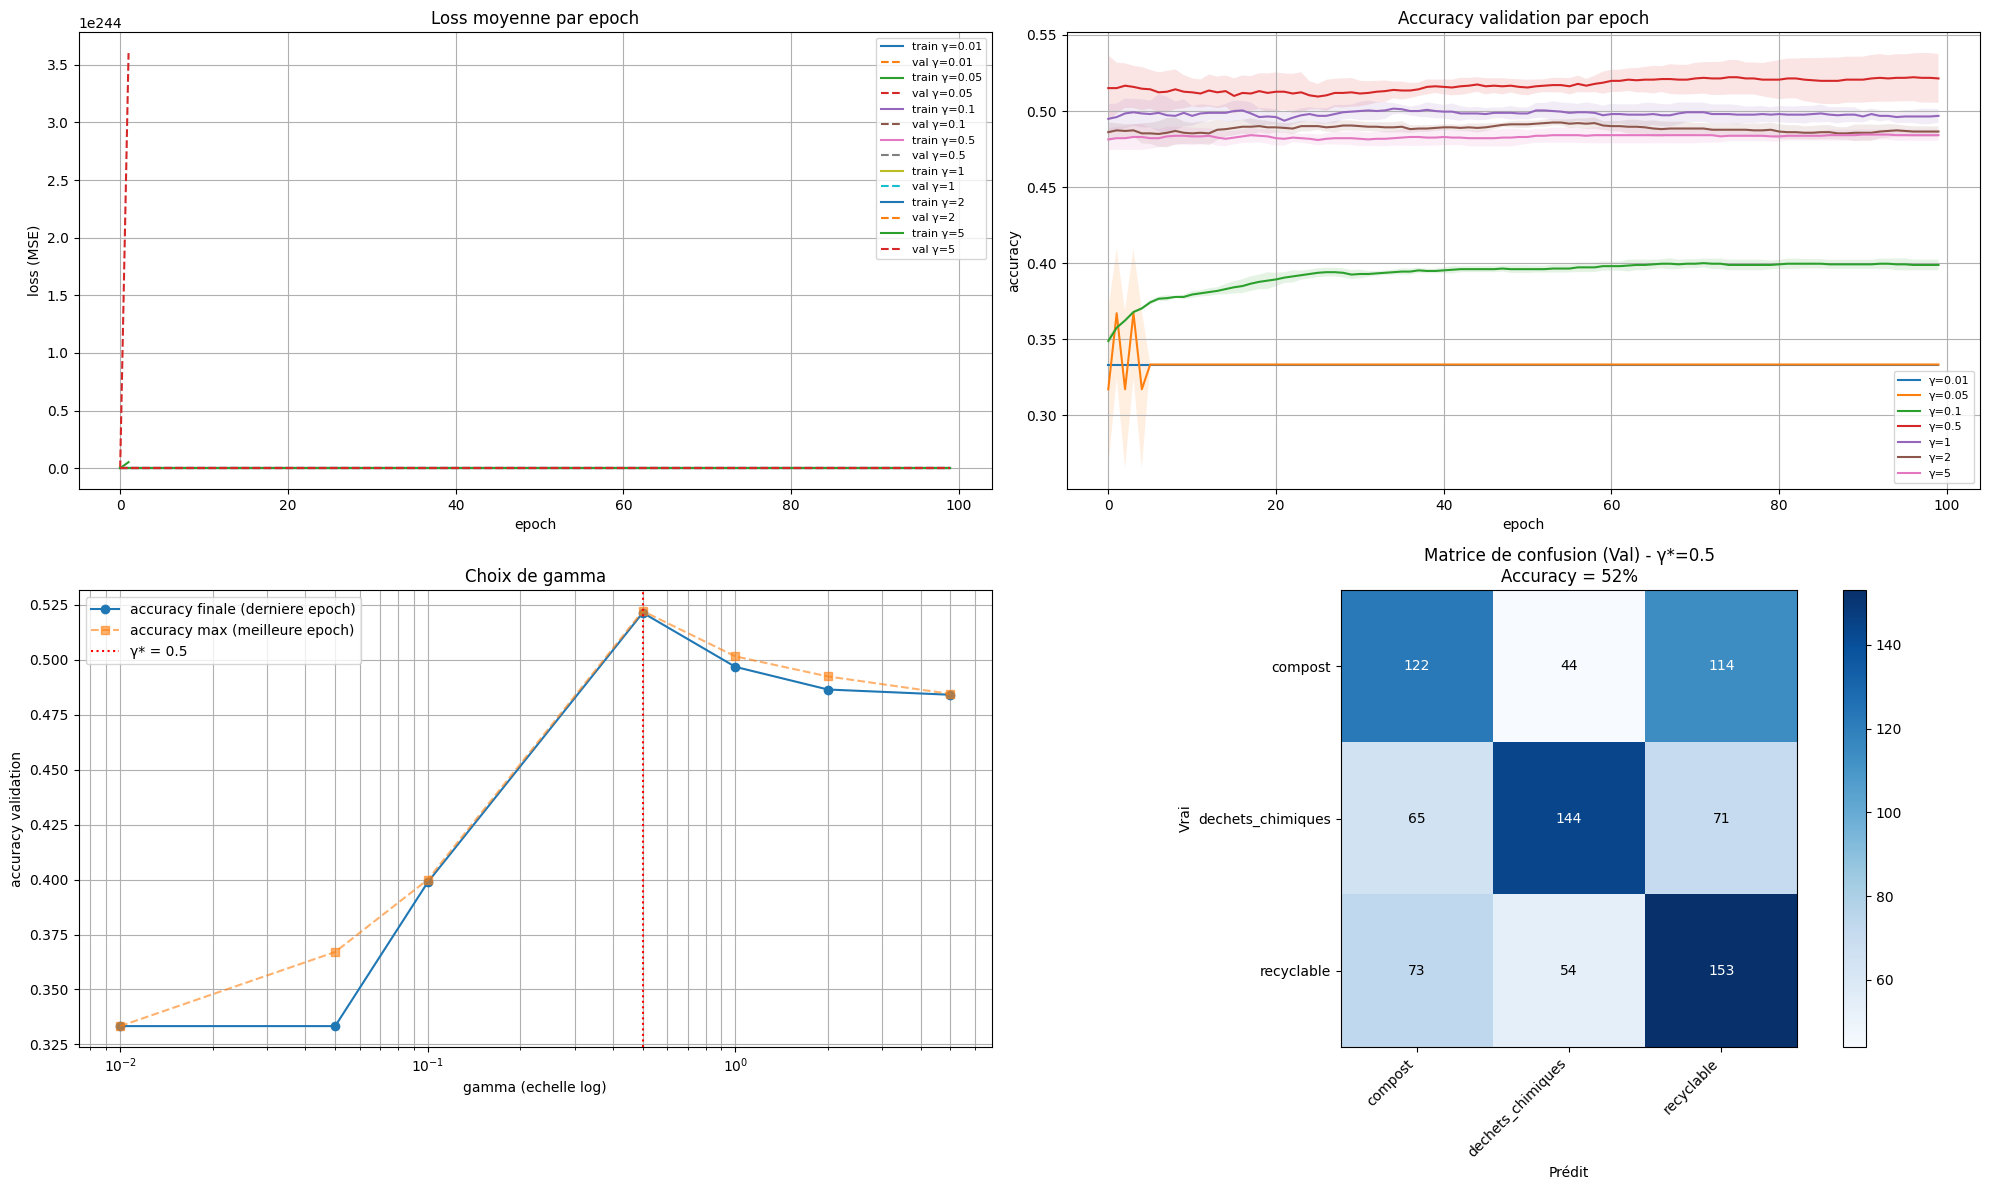

In [10]:
# ================== BLOC PLOT UNIQUE (sweep gamma) ==================
gammas_done = list(results_par_k.keys())
epochs      = np.arange(nb_epoch)

# resumes par gamma
val_acc_final = [results_par_k[g]["accs_mean"][-1]  for g in gammas_done]  # derniere epoch
val_acc_max   = [results_par_k[g]["accs_mean"].max() for g in gammas_done] # meilleure epoch
gamma_star    = gammas_done[int(np.argmax(val_acc_final))]                 # gamma retenu

fig, ((axA, axB), (axC, axD)) = plt.subplots(2, 2, figsize=(20, 12))

# --- A : loss par epoch ---
for g in gammas_done:
    r = results_par_k[g]
    axA.plot(epochs, r["train_loss_mean"], label=f"train γ={g}")
    axA.plot(epochs, r["val_loss_mean"], "--", label=f"val γ={g}")
axA.set_xlabel("epoch"); axA.set_ylabel("loss (MSE)")
axA.set_title("Loss moyenne par epoch"); axA.legend(fontsize=8); axA.grid(True)

# --- B : accuracy par epoch ---
for g in gammas_done:
    r = results_par_k[g]
    axB.plot(epochs, r["accs_mean"], label=f"γ={g}")
    axB.fill_between(epochs, r["accs_mean"] - r["accs_std"],
                     r["accs_mean"] + r["accs_std"], alpha=0.12)
axB.set_xlabel("epoch"); axB.set_ylabel("accuracy")
axB.set_title("Accuracy validation par epoch"); axB.legend(fontsize=8); axB.grid(True)

# --- C : choix de gamma (echelle log en X) ---
axC.plot(gammas_done, val_acc_final, "o-", label="accuracy finale (derniere epoch)")
axC.plot(gammas_done, val_acc_max, "s--", alpha=0.6, label="accuracy max (meilleure epoch)")
axC.axvline(gamma_star, color="red", linestyle=":", label=f"γ* = {gamma_star}")
axC.set_xscale("log")
axC.set_xlabel("gamma (echelle log)"); axC.set_ylabel("accuracy validation")
axC.set_title("Choix de gamma"); axC.legend(); axC.grid(True, which="both")

# --- D : matrice de confusion au gamma retenu ---
model_star = results_par_k[gamma_star]["model"]
cm = confusion_matrix(y_val, model_star.predict(X_val), 3)

im = axD.imshow(cm, cmap="Blues")
axD.set_xticks(range(3)); axD.set_xticklabels(classes, rotation=45, ha="right")
axD.set_yticks(range(3)); axD.set_yticklabels(classes)
axD.set_xlabel("Prédit"); axD.set_ylabel("Vrai")
axD.set_title(f"Matrice de confusion (Val) - γ*={gamma_star}\n"
              f"Accuracy = {val_acc_final[gammas_done.index(gamma_star)]*100:.0f}%")
thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        axD.text(j, i, int(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
fig.colorbar(im, ax=axD)

plt.tight_layout()
plt.show()

In [9]:
seeds_list = [
    [6, 8, 12, 48, 75]
    ,[1, 5, 142, 24, 12]
    ,[3, 8, 9]
]

gammas = [.3, .4, .5, .6, .7] # 0.5

# HP
nb_epoch      = 100
learning_rate = 0.1
gamma         = 0.5
seeds         = seeds_list[2]
#list_nb_centre = np.arange(1500, 2000, 100)
nb_centre = 1800

# Train
results_par_g = {}
for g in gammas:
     #c = int(c)
    print(f"Batch gamma -> {g}")
    results_par_g[g] = rbf_classification_training(
                            nb_epoch=nb_epoch,
                            learning_rate=learning_rate,
                            nb_centre=nb_centre,
                            gamma=g,
                            seeds=seeds,
                            X_train=X_train, X_val=X_val,
                            y_train=y_train, y_val=y_val,
                        )

Batch gamma -> 0.3


seed=9: 100%|██████████| 100/100 [08:39<00:00,  5.20s/it, acc=0.524, train=0.0995, val=0.2728]


Batch gamma -> 0.4


seed=9: 100%|██████████| 100/100 [08:39<00:00,  5.20s/it, acc=0.515, train=0.1143, val=0.2888]


Batch gamma -> 0.5


seed=9: 100%|██████████| 100/100 [09:00<00:00,  5.41s/it, acc=0.499, train=0.1249, val=0.2984]


Batch gamma -> 0.6


seed=9: 100%|██████████| 100/100 [08:38<00:00,  5.18s/it, acc=0.504, train=0.1315, val=0.3036]


Batch gamma -> 0.7


seed=9: 100%|██████████| 100/100 [09:01<00:00,  5.42s/it, acc=0.507, train=0.1356, val=0.3062]


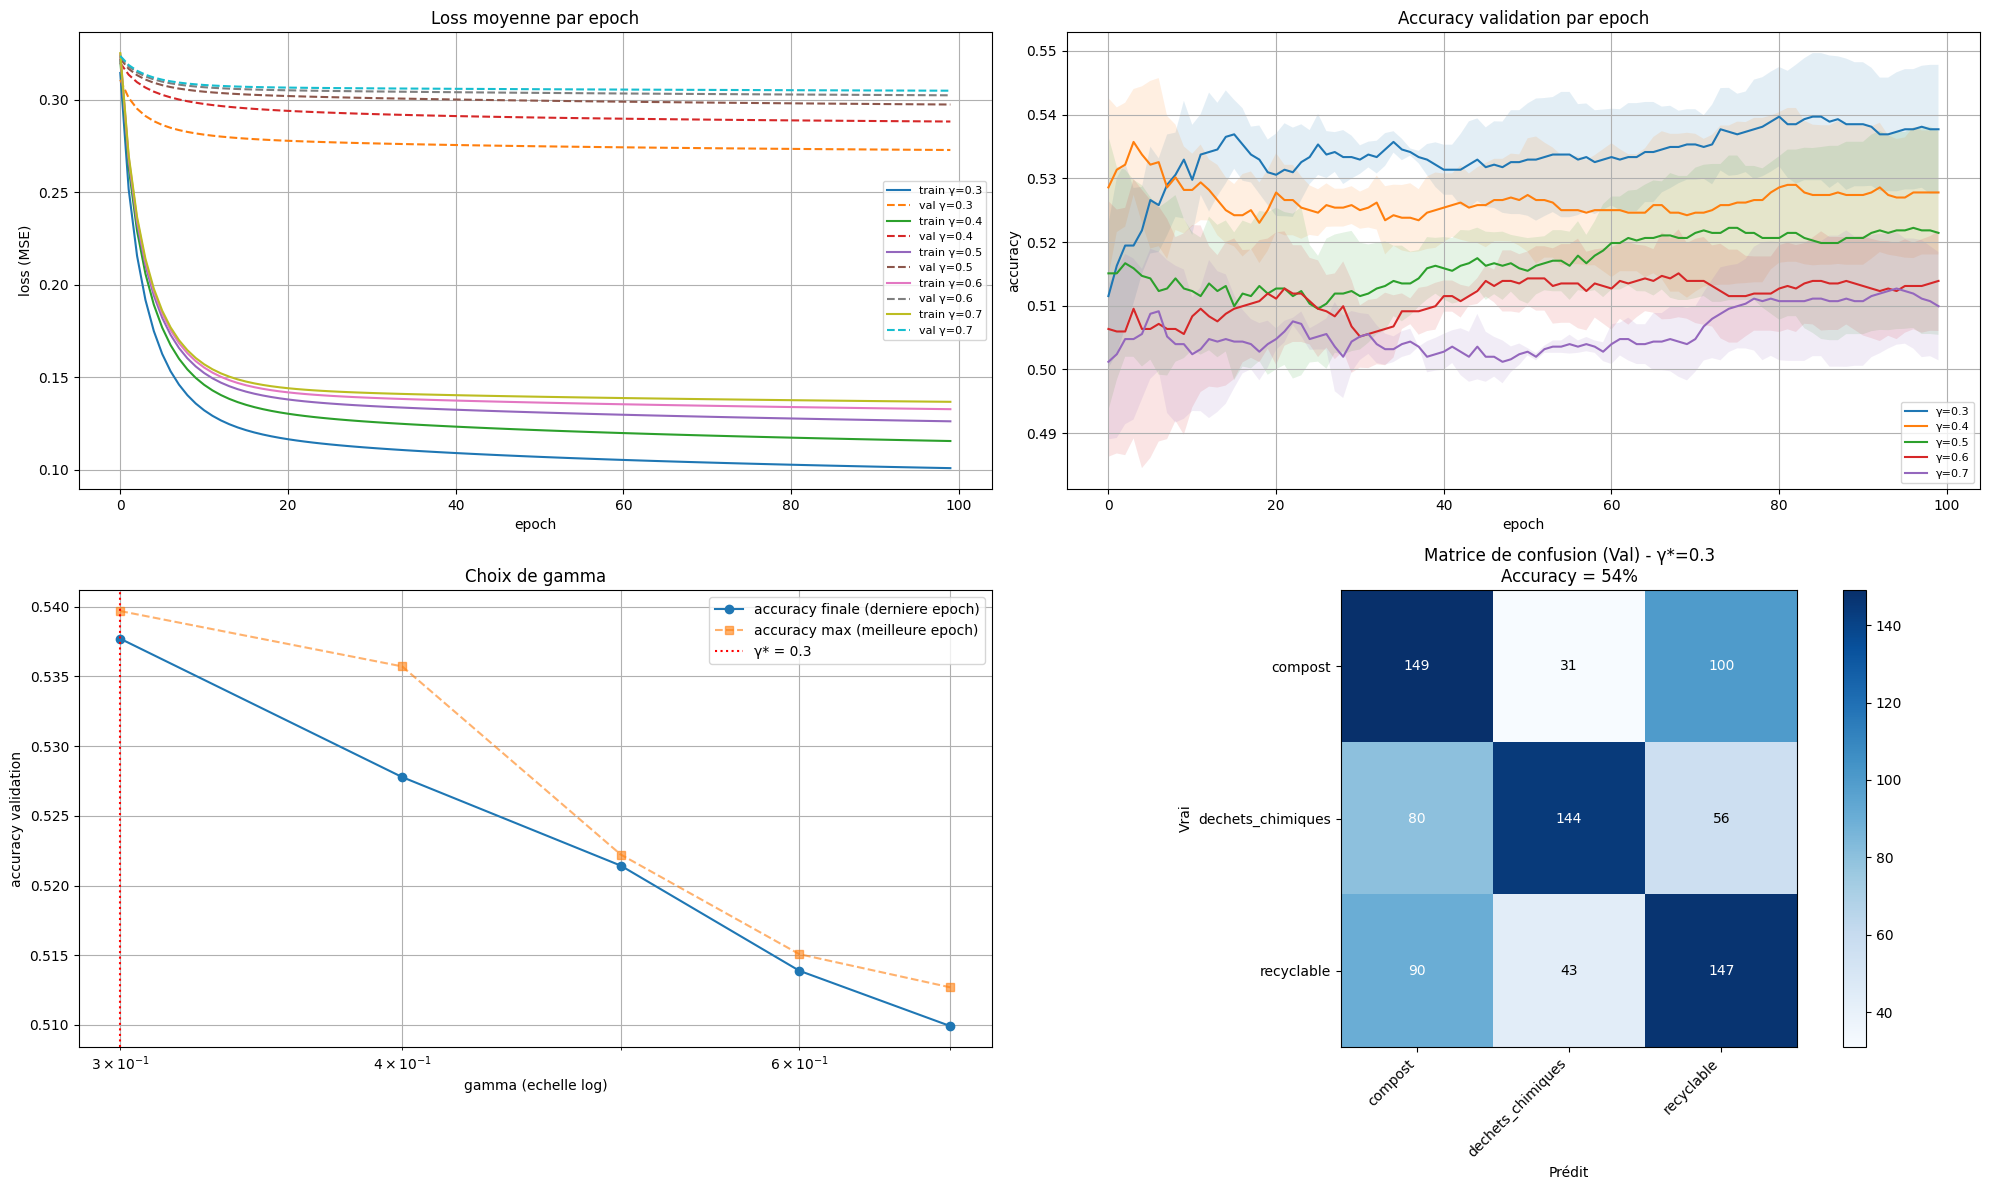

In [11]:
# ================== BLOC PLOT UNIQUE (sweep gamma) ==================
gammas_done = list(results_par_g.keys())
epochs      = np.arange(nb_epoch)

# resumes par gamma
val_acc_final = [results_par_g[g]["accs_mean"][-1]  for g in gammas_done]  # derniere epoch
val_acc_max   = [results_par_g[g]["accs_mean"].max() for g in gammas_done] # meilleure epoch
gamma_star    = gammas_done[int(np.argmax(val_acc_final))]                 # gamma retenu

fig, ((axA, axB), (axC, axD)) = plt.subplots(2, 2, figsize=(20, 12))

# --- A : loss par epoch ---
for g in gammas_done:
    r = results_par_g[g]
    axA.plot(epochs, r["train_loss_mean"], label=f"train γ={g}")
    axA.plot(epochs, r["val_loss_mean"], "--", label=f"val γ={g}")
axA.set_xlabel("epoch"); axA.set_ylabel("loss (MSE)")
axA.set_title("Loss moyenne par epoch"); axA.legend(fontsize=8); axA.grid(True)

# --- B : accuracy par epoch ---
for g in gammas_done:
    r = results_par_g[g]
    axB.plot(epochs, r["accs_mean"], label=f"γ={g}")
    axB.fill_between(epochs, r["accs_mean"] - r["accs_std"],
                     r["accs_mean"] + r["accs_std"], alpha=0.12)
axB.set_xlabel("epoch"); axB.set_ylabel("accuracy")
axB.set_title("Accuracy validation par epoch"); axB.legend(fontsize=8); axB.grid(True)

# --- C : choix de gamma (echelle log en X) ---
axC.plot(gammas_done, val_acc_final, "o-", label="accuracy finale (derniere epoch)")
axC.plot(gammas_done, val_acc_max, "s--", alpha=0.6, label="accuracy max (meilleure epoch)")
axC.axvline(gamma_star, color="red", linestyle=":", label=f"γ* = {gamma_star}")
axC.set_xscale("log")
axC.set_xlabel("gamma (echelle log)"); axC.set_ylabel("accuracy validation")
axC.set_title("Choix de gamma"); axC.legend(); axC.grid(True, which="both")

# --- D : matrice de confusion au gamma retenu ---
model_star = results_par_g[gamma_star]["model"]
cm = confusion_matrix(y_val, model_star.predict(X_val), 3)

im = axD.imshow(cm, cmap="Blues")
axD.set_xticks(range(3)); axD.set_xticklabels(classes, rotation=45, ha="right")
axD.set_yticks(range(3)); axD.set_yticklabels(classes)
axD.set_xlabel("Prédit"); axD.set_ylabel("Vrai")
axD.set_title(f"Matrice de confusion (Val) - γ*={gamma_star}\n"
              f"Accuracy = {val_acc_final[gammas_done.index(gamma_star)]*100:.0f}%")
thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        axD.text(j, i, int(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
fig.colorbar(im, ax=axD)

plt.tight_layout()
plt.show()

Maintenant qu'on a trouvé un gamma et un kcentre ok, tester avec plus de seeds

In [16]:
seeds_list = [
    [6, 8, 12, 48, 75]
    ,[1, 5, 142, 24, 12]
    ,[3, 8, 9]
    ,[3, 8, 9, 11, 14, 56, 85, 55, 15, 75, 5, 12, 63, 41, 31]
]

gammas = [.3, .4, .5, .6, .7] # 0.5

# HP
nb_epoch      = 100
learning_rate = 0.1
gamma         = 0.3
seeds         = seeds_list[3]
#list_nb_centre = np.arange(1500, 2000, 100)
nb_centre = 1800

# Train
training_output_u_multi_seeds = rbf_classification_training(
                                    nb_epoch=nb_epoch,
                                    learning_rate=learning_rate,
                                    nb_centre=nb_centre,
                                    gamma=gamma,
                                    seeds=seeds,
                                    X_train=X_train, X_val=X_val,
                                    y_train=y_train, y_val=y_val,
                                )

seed=31: 100%|██████████| 100/100 [08:37<00:00,  5.18s/it, acc=0.525, train=0.1041, val=0.2748]


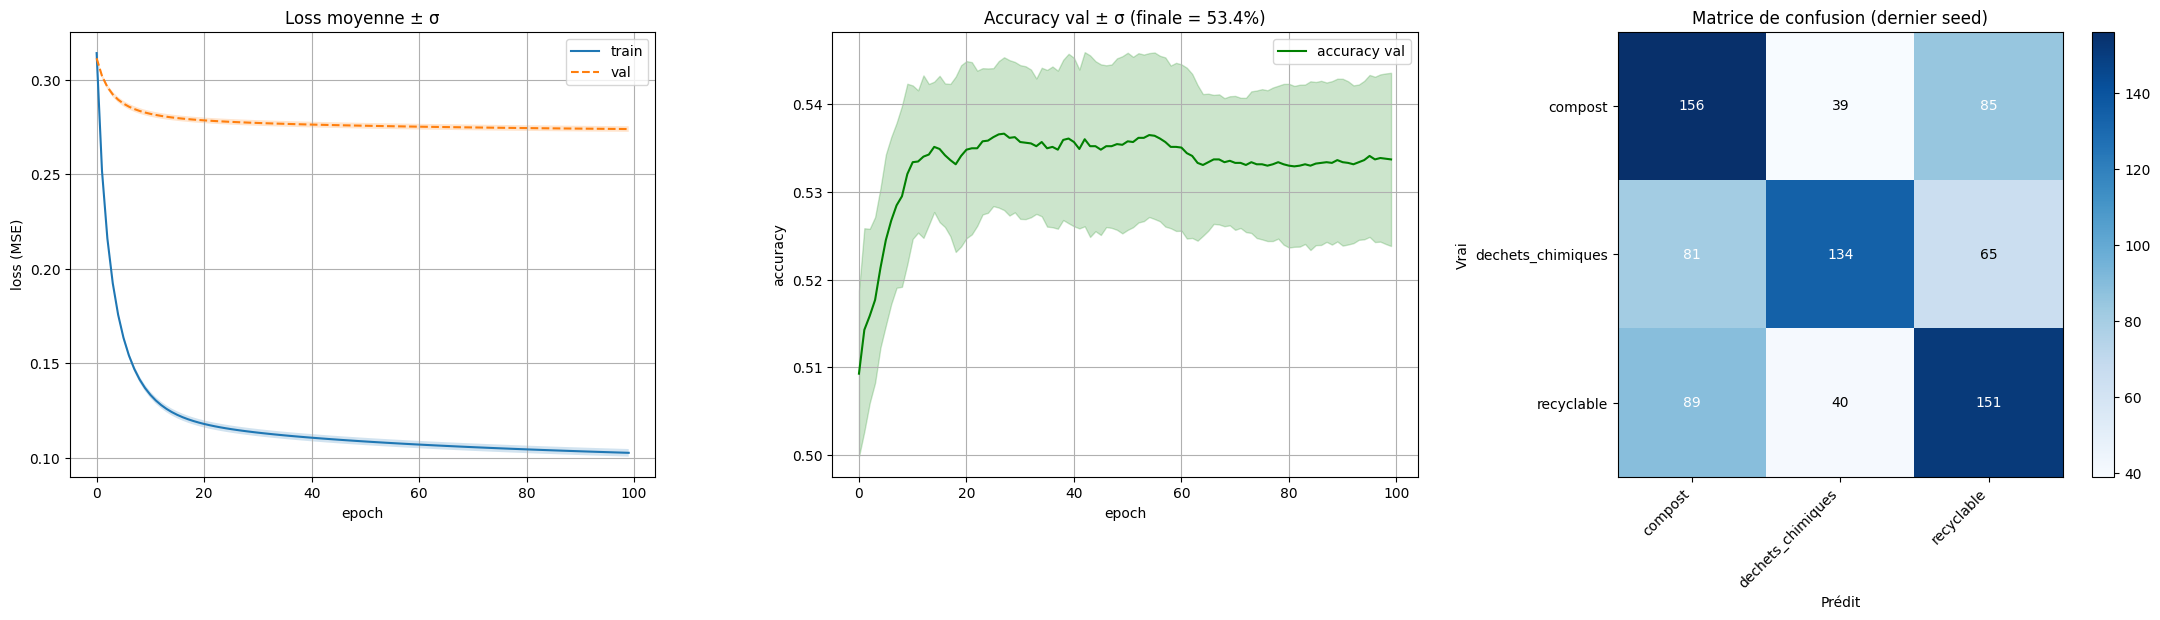

In [17]:
# ================== BLOC PLOT (run unique, multi-seed) ==================
r      = training_output_u_multi_seeds
epochs = np.arange(nb_epoch)

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(22, 6))

# --- A : loss train + val avec bandes ecart-type ---
axA.plot(epochs, r["train_loss_mean"], label="train")
axA.fill_between(epochs, r["train_loss_mean"] - r["train_loss_std"],
                 r["train_loss_mean"] + r["train_loss_std"], alpha=0.2)
axA.plot(epochs, r["val_loss_mean"], "--", label="val")
axA.fill_between(epochs, r["val_loss_mean"] - r["val_loss_std"],
                 r["val_loss_mean"] + r["val_loss_std"], alpha=0.2)
axA.set_xlabel("epoch"); axA.set_ylabel("loss (MSE)")
axA.set_title("Loss moyenne ± σ"); axA.legend(); axA.grid(True)

# --- B : accuracy val avec bande ---
axB.plot(epochs, r["accs_mean"], color="green", label="accuracy val")
axB.fill_between(epochs, r["accs_mean"] - r["accs_std"],
                 r["accs_mean"] + r["accs_std"], alpha=0.2, color="green")
axB.set_xlabel("epoch"); axB.set_ylabel("accuracy")
axB.set_title(f"Accuracy val ± σ (finale = {r['accs_mean'][-1]*100:.1f}%)")
axB.legend(); axB.grid(True)

# --- C : matrice de confusion (ATTENTION: dernier seed uniquement) ---
model = r["model"]
cm = confusion_matrix(y_val, model.predict(X_val), 3)
im = axC.imshow(cm, cmap="Blues")
axC.set_xticks(range(3)); axC.set_xticklabels(classes, rotation=45, ha="right")
axC.set_yticks(range(3)); axC.set_yticklabels(classes)
axC.set_xlabel("Prédit"); axC.set_ylabel("Vrai")
axC.set_title("Matrice de confusion (dernier seed)")
thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        axC.text(j, i, int(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
fig.colorbar(im, ax=axC)

plt.tight_layout()
plt.show()

# gamma 0.3 24*24 kmpp | test de nb centre (faibles nb)

In [21]:
seeds_list = [
    [6, 8, 12, 48, 75]
    ,[1, 5, 142, 24, 12]
    ,[3, 8, 9]
]

gammas = [0.01, 0.1, 0.5, 0.8, 2] # 0.5

# HP
nb_epoch      = 100
learning_rate = 0.1
gamma         = 0.5
seeds         = seeds_list[2]
list_nb_centre = np.arange(100, 1500, 100)

# Train
results_par_k = {}
for c in list_nb_centre:
    c = int(c)
    print(f"Batch nb_centre -> {c}")
    results_par_k[c] = rbf_classification_training(
                            nb_epoch=nb_epoch,
                            learning_rate=learning_rate,
                            nb_centre=c,
                            gamma=gamma,
                            seeds=seeds,
                            X_train=X_train, X_val=X_val,
                            y_train=y_train, y_val=y_val,
                        )

Batch nb_centre -> 100


seed=9: 100%|██████████| 100/100 [00:30<00:00,  3.32it/s, acc=0.421, train=0.3132, val=0.3233]


Batch nb_centre -> 200


seed=9: 100%|██████████| 100/100 [01:01<00:00,  1.63it/s, acc=0.440, train=0.3009, val=0.3216]


Batch nb_centre -> 300


...

seed=9: 100%|██████████| 100/100 [05:56<00:00,  3.57s/it, acc=0.492, train=0.1776, val=0.3021]


Batch nb_centre -> 1300


seed=9: 100%|██████████| 100/100 [06:23<00:00,  3.84s/it, acc=0.501, train=0.1667, val=0.3016]


Batch nb_centre -> 1400


seed=9: 100%|██████████| 100/100 [07:18<00:00,  4.39s/it, acc=0.514, train=0.1576, val=0.3008]


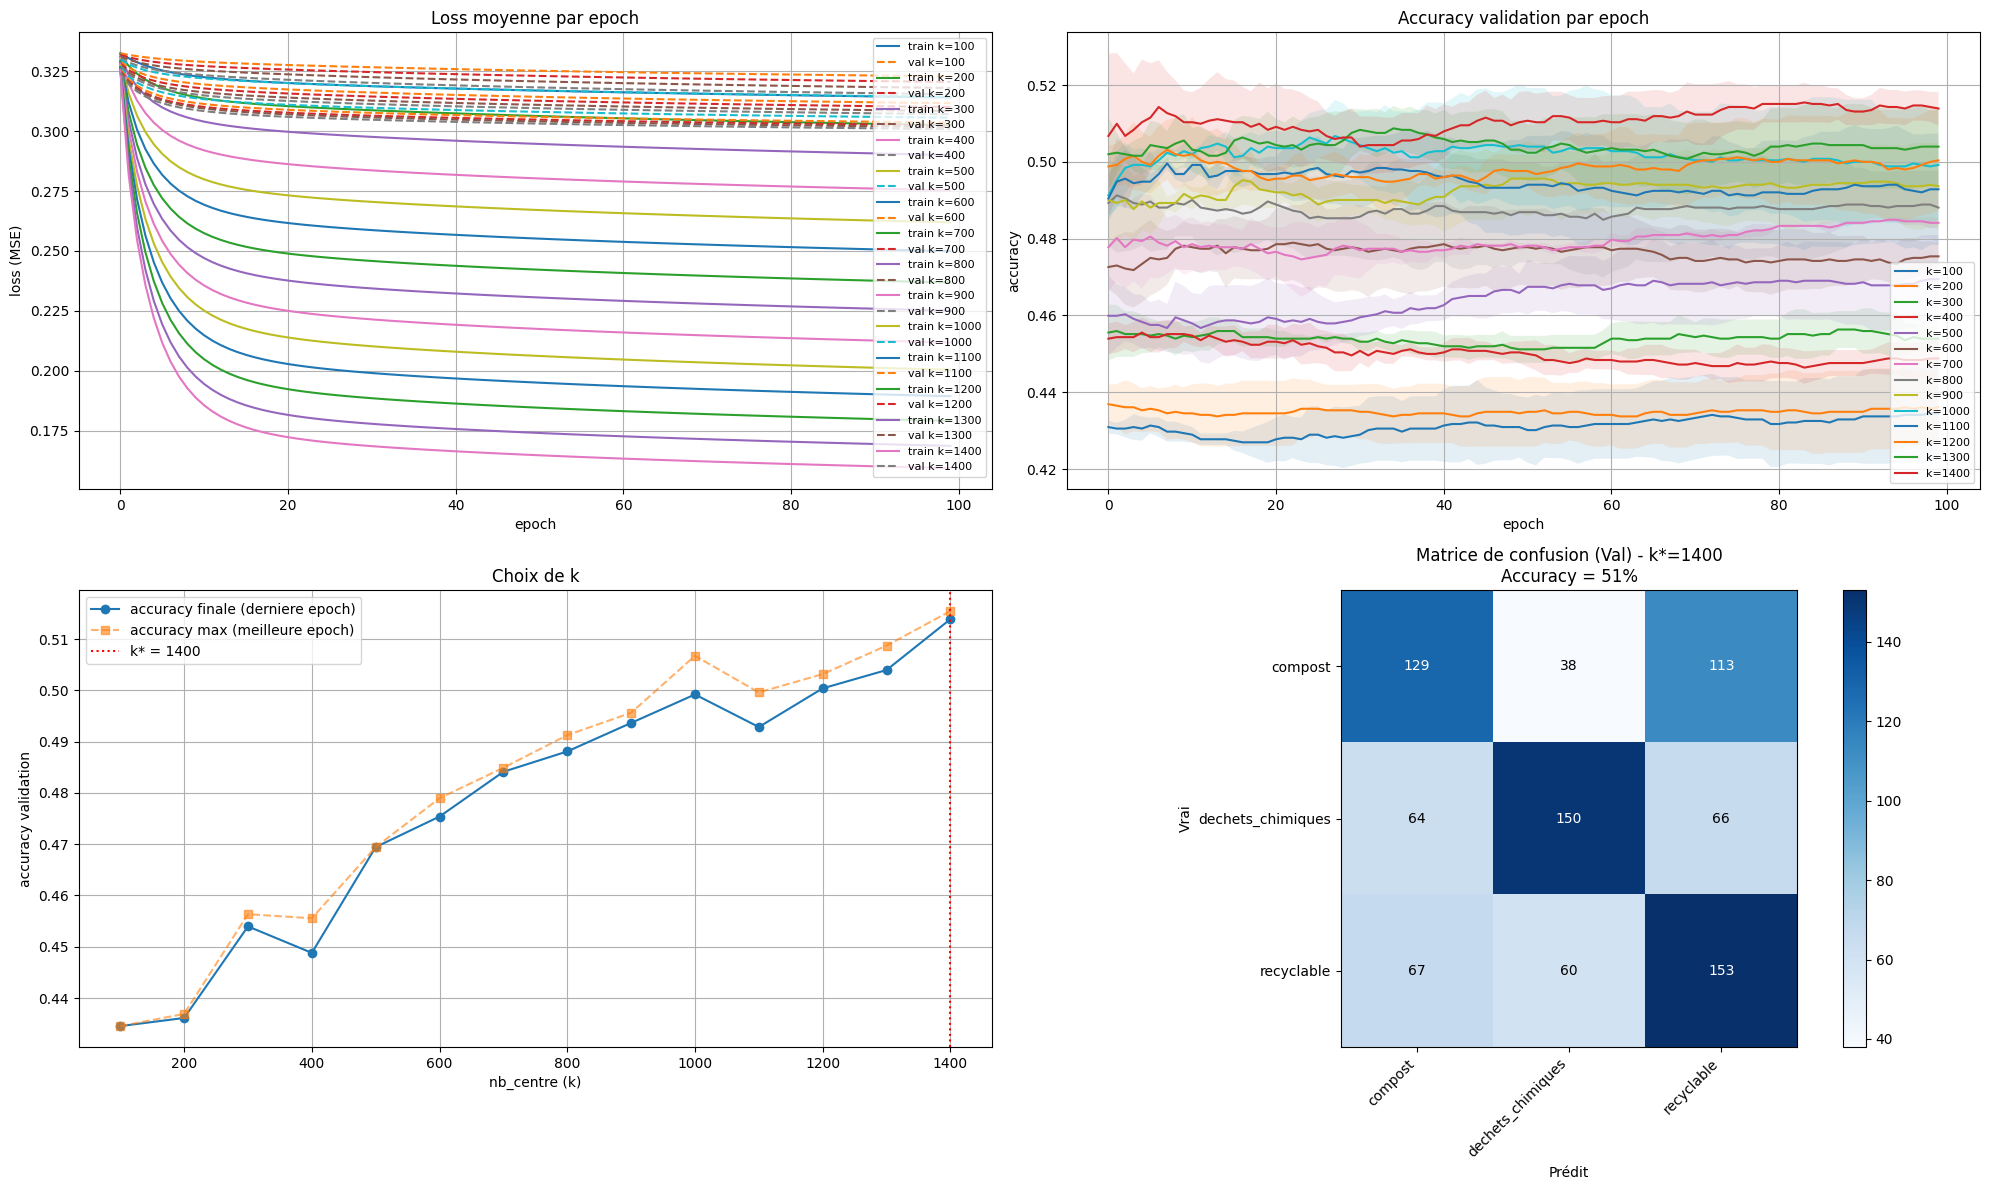

In [22]:

ks     = list(results_par_k.keys())
epochs = np.arange(nb_epoch)

# resumes par k
val_acc_final = [results_par_k[c]["accs_mean"][-1]  for c in ks]  # derniere epoch
val_acc_max   = [results_par_k[c]["accs_mean"].max() for c in ks] # meilleure epoch
k_star        = ks[int(np.argmax(val_acc_final))]                 # k retenu

fig, ((axA, axB), (axC, axD)) = plt.subplots(2, 2, figsize=(20, 12))

# --- A : loss par epoch ---
for c in ks:
    r = results_par_k[c]
    axA.plot(epochs, r["train_loss_mean"], label=f"train k={c}")
    axA.plot(epochs, r["val_loss_mean"], "--", label=f"val k={c}")
axA.set_xlabel("epoch"); axA.set_ylabel("loss (MSE)")
axA.set_title("Loss moyenne par epoch"); axA.legend(fontsize=8); axA.grid(True)

# --- B : accuracy par epoch (sert a regler nb_epoch) ---
for c in ks:
    r = results_par_k[c]
    axB.plot(epochs, r["accs_mean"], label=f"k={c}")
    axB.fill_between(epochs, r["accs_mean"] - r["accs_std"],
                     r["accs_mean"] + r["accs_std"], alpha=0.12)
axB.set_xlabel("epoch"); axB.set_ylabel("accuracy")
axB.set_title("Accuracy validation par epoch"); axB.legend(fontsize=8); axB.grid(True)

# --- C : choix de k ---
axC.plot(ks, val_acc_final, "o-", label="accuracy finale (derniere epoch)")
axC.plot(ks, val_acc_max, "s--", alpha=0.6, label="accuracy max (meilleure epoch)")
axC.axvline(k_star, color="red", linestyle=":", label=f"k* = {k_star}")
axC.set_xlabel("nb_centre (k)"); axC.set_ylabel("accuracy validation")
axC.set_title("Choix de k"); axC.legend(); axC.grid(True)

# --- D : matrice de confusion au k retenu ---
model_star = results_par_k[k_star]["model"]
cm = confusion_matrix(y_val, model_star.predict(X_val), 3)

im = axD.imshow(cm, cmap="Blues")
axD.set_xticks(range(3)); axD.set_xticklabels(classes, rotation=45, ha="right")
axD.set_yticks(range(3)); axD.set_yticklabels(classes)
axD.set_xlabel("Prédit"); axD.set_ylabel("Vrai")
axD.set_title(f"Matrice de confusion (Val) - k*={k_star}\n"
              f"Accuracy = {val_acc_final[ks.index(k_star)]*100:.0f}%")
thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        axD.text(j, i, int(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
fig.colorbar(im, ax=axD)

plt.tight_layout()
plt.show()

In [24]:
seeds_list = [
    [6, 8, 12, 48, 75]
    ,[1, 5, 142, 24, 12]
    ,[3, 8, 9]
]

gammas = [0.01, 0.1, 0.5, 0.8, 2] # 0.5

# HP
nb_epoch      = 100
learning_rate = 0.1
gamma         = 0.5
seeds         = seeds_list[2]
list_nb_centre = np.arange(100, 2000, 100)

# Train
results_par_k = {}
for c in list_nb_centre:
    c = int(c)
    print(f"Batch nb_centre -> {c}")
    results_par_k[c] = rbf_classification_training(
                            nb_epoch=nb_epoch,
                            learning_rate=learning_rate,
                            nb_centre=c,
                            gamma=gamma,
                            seeds=seeds,
                            X_train=X_train, X_val=X_val,
                            y_train=y_train, y_val=y_val,
                        )

Batch nb_centre -> 100


seed=9: 100%|██████████| 100/100 [00:32<00:00,  3.09it/s, acc=0.421, train=0.3132, val=0.3233]


Batch nb_centre -> 200


seed=9: 100%|██████████| 100/100 [01:04<00:00,  1.56it/s, acc=0.440, train=0.3009, val=0.3216]


Batch nb_centre -> 300


...

seed=9: 100%|██████████| 100/100 [10:23<00:00,  6.24s/it, acc=0.502, train=0.1316, val=0.2992]


Batch nb_centre -> 1800


seed=9: 100%|██████████| 100/100 [10:44<00:00,  6.45s/it, acc=0.499, train=0.1249, val=0.2984]


Batch nb_centre -> 1900


seed=9: 100%|██████████| 100/100 [09:44<00:00,  5.85s/it, acc=0.504, train=0.1185, val=0.2979]


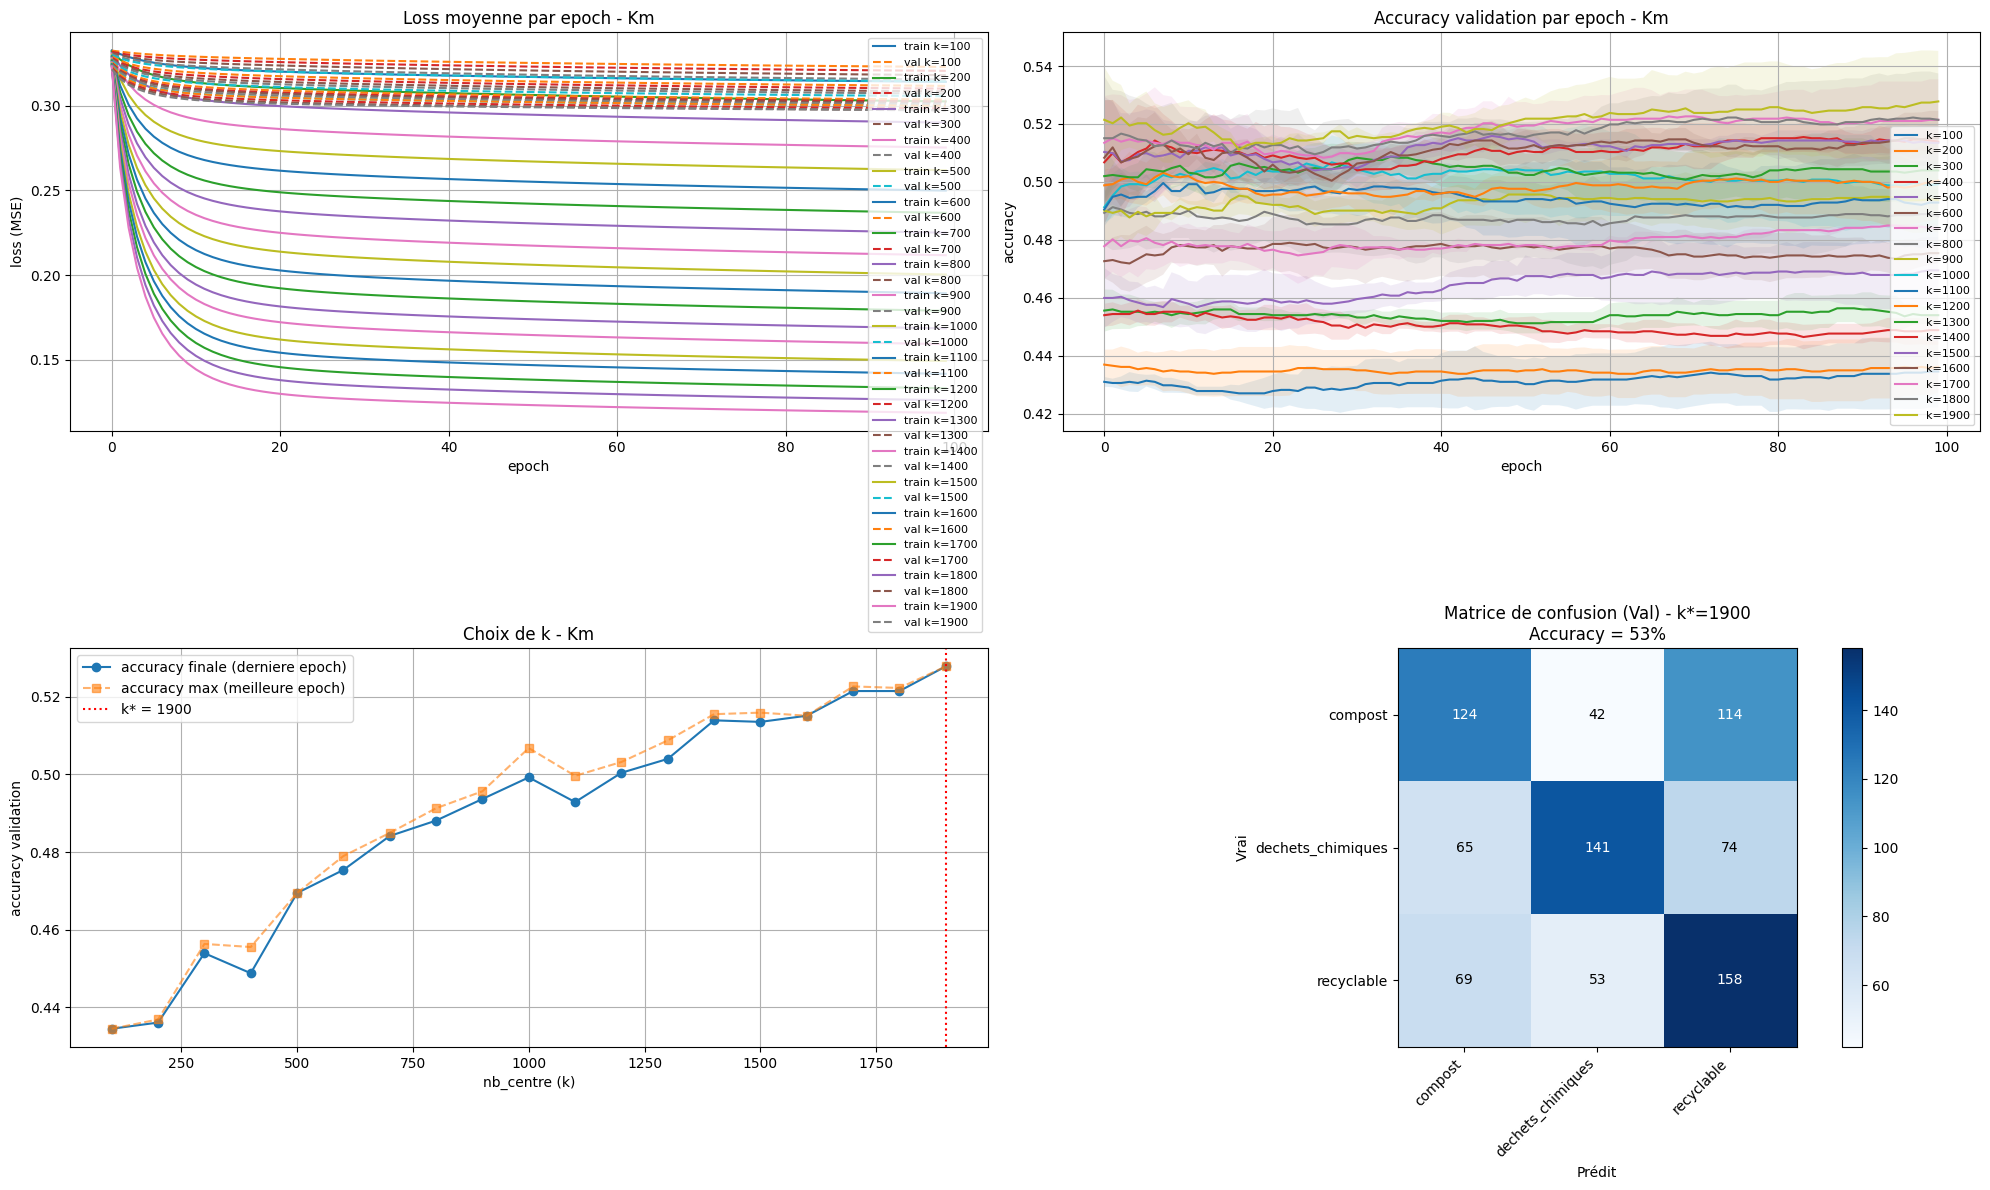

: 

In [ ]:

ks     = list(results_par_k.keys())
epochs = np.arange(nb_epoch)

# resumes par k
val_acc_final = [results_par_k[c]["accs_mean"][-1]  for c in ks]  # derniere epoch
val_acc_max   = [results_par_k[c]["accs_mean"].max() for c in ks] # meilleure epoch
k_star        = ks[int(np.argmax(val_acc_final))]                 # k retenu

fig, ((axA, axB), (axC, axD)) = plt.subplots(2, 2, figsize=(20, 12))

# --- A : loss par epoch ---
for c in ks:
    r = results_par_k[c]
    axA.plot(epochs, r["train_loss_mean"], label=f"train k={c}")
    axA.plot(epochs, r["val_loss_mean"], "--", label=f"val k={c}")
axA.set_xlabel("epoch"); axA.set_ylabel("loss (MSE)")
axA.set_title("Loss moyenne par epoch - Km"); axA.legend(fontsize=8); axA.grid(True)

# --- B : accuracy par epoch (sert a regler nb_epoch) ---
for c in ks:
    r = results_par_k[c]
    axB.plot(epochs, r["accs_mean"], label=f"k={c}")
    axB.fill_between(epochs, r["accs_mean"] - r["accs_std"],
                     r["accs_mean"] + r["accs_std"], alpha=0.12)
axB.set_xlabel("epoch"); axB.set_ylabel("accuracy")
axB.set_title("Accuracy validation par epoch - Km"); axB.legend(fontsize=8); axB.grid(True)

# --- C : choix de k ---
axC.plot(ks, val_acc_final, "o-", label="accuracy finale (derniere epoch)")
axC.plot(ks, val_acc_max, "s--", alpha=0.6, label="accuracy max (meilleure epoch)")
axC.axvline(k_star, color="red", linestyle=":", label=f"k* = {k_star}")
axC.set_xlabel("nb_centre (k)"); axC.set_ylabel("accuracy validation")
axC.set_title("Choix de k - Km"); axC.legend(); axC.grid(True)

# --- D : matrice de confusion au k retenu ---
model_star = results_par_k[k_star]["model"]
cm = confusion_matrix(y_val, model_star.predict(X_val), 3)

im = axD.imshow(cm, cmap="Blues")
axD.set_xticks(range(3)); axD.set_xticklabels(classes, rotation=45, ha="right")
axD.set_yticks(range(3)); axD.set_yticklabels(classes)
axD.set_xlabel("Prédit"); axD.set_ylabel("Vrai")
axD.set_title(f"Matrice de confusion (Val) - k*={k_star}\n"
              f"Accuracy = {val_acc_final[ks.index(k_star)]*100:.0f}%")
thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        axD.text(j, i, int(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
fig.colorbar(im, ax=axD)

plt.tight_layout()
plt.show()